In [9]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Literal

In [45]:
class EquationState(TypedDict):
    a : int 
    b : int 
    c : int 
    equation :str
    d : float 
    result :str

In [46]:
def show_equation(state:EquationState) : 
    print(f"{state['a']}x^2 + {state['b']}x + {state['c']} = 0 ")
    return state

In [59]:
def find_D(state:EquationState) -> EquationState :
    state['d'] = (state['b']**2.0 - (4*state['a']*state['c']))
    return state

In [60]:
def real_distinct_Roots(state: EquationState):
    sqrt_d = state['d'] ** 0.5
    r1 = (-state['b'] + sqrt_d) / (2.0 * state['a'])
    r2 = (-state['b'] - sqrt_d) / (2.0 * state['a'])
    
    state['result'] = f"the equation has real and distinct roots : {r1} and {r2}" 
    return state

In [61]:
def real_equal_Roots(state: EquationState): 
    r = (-state['b']) / (2.0 * state['a'])
    
    state['result'] = f"the equation has real and equal roots and that is {r}"
    return state 

In [62]:
def imaginary_Roots(state:EquationState):
    state['result'] = f"the equation doens't have real roots "
    return state

In [63]:
def check_condition(state:EquationState) -> Literal['real_distinct_Roots','imaginary_Roots','real_equal_Roots'] :
    if (state['d'] > 0 ) :
        return 'real_distinct_Roots'
    elif state['d'] == 0 : 
        return 'real_equal_Roots'
    else : 
        return 'imagniary_Roots'


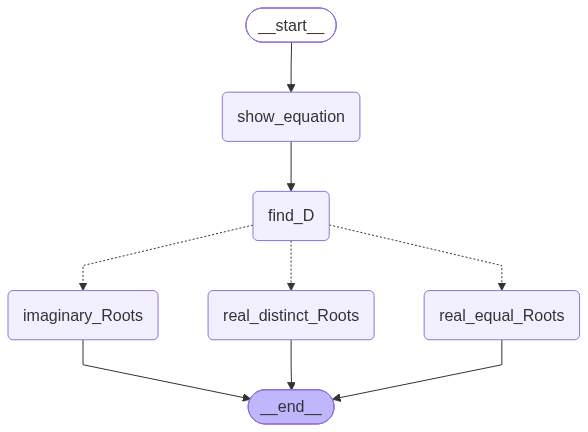

In [64]:
graph = StateGraph(EquationState)

graph.add_node('show_equation',show_equation)
graph.add_node('real_distinct_Roots',real_distinct_Roots)
graph.add_node('real_equal_Roots',real_equal_Roots)
graph.add_node('imaginary_Roots',imaginary_Roots)
graph.add_node('find_D',find_D)
graph.add_edge(START,'show_equation')
graph.add_edge('show_equation','find_D')
# graph.add_edge('find_D',END)
graph.add_conditional_edges('find_D',check_condition)
graph.add_edge('real_equal_Roots',END)
graph.add_edge('real_distinct_Roots',END)
graph.add_edge('imaginary_Roots',END)

workflow =graph.compile()
workflow

In [65]:
final_state = workflow.invoke({'a':4,'b':-5,'c':-4})
final_state

4x^2 + -5x + -4 = 0 


{'a': 4,
 'b': -5,
 'c': -4,
 'd': 89.0,
 'result': 'the equation has real and distinct roots : 1.8042476415070754 and -0.5542476415070754'}